# Alignment Neuroendocrine 
Integrate scRNA-seq from PNECs in NEr-fAOs to PNECs derived from other published in vitro human airway models, and in vivo lung epithelial cells

Hor_2020_iPNECs: Efficient generation and transcriptomic profiling of human iPSC-derived pulmonary neuroendocrine cells.
Conchola_2023: PNEC from primary human bud tip organoids (BTOs).
Lee_2023: PNEC from A single-cell atlas of in vitro multiculture systems.

Conchola2023: single-cell RNA sequencing (scRNA-seq) dataset characterizing the human fetal lung epithelium from 8 to 21 wk postconception
Guo2023: This atlas spans sc/snRNA-seq of 505,256 lung cells from 148 normal human lung samples from 104 donors from parenchyma, trachea, bonchi, bronchus SMG and small airway

## Imports

In [29]:
import scanpy as sc
import pandas as pd
import numpy as np
import os, tqdm
from os import listdir
from os.path import isfile, join
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import csv
from gtfparse import read_gtf
import hdf5plugin
import seaborn as sns
import scanpy.external as sce
import anndata as ad
from scipy.sparse import hstack
from collections import Counter
import biomart 
from biomart import BiomartServer
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.sparse import csr_matrix

## Custom colormap

/tmp/ipykernel_1872761/3726451157.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  YlGnBu_cmap = plt.cm.get_cmap('YlGnBu')


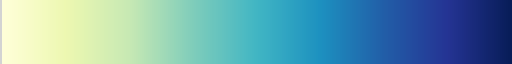

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Define the 'lightgrey' color as an RGBA tuple with values in the range 0-1
lightgrey_rgba = (0.83, 0.83, 0.83, 1.0)  # RGB values for lightgrey with alpha=1.0
# Get the 'YlGnBu' colormap
YlGnBu_cmap = plt.cm.get_cmap('YlGnBu')
# Define the number of steps for interpolation
num_steps = 256
# Define the range for values where lightgrey is used
lightgrey_range = 0.0
# Interpolate between light grey and blue for values from 0 to lightgrey_range
interpolated_colors_below = [lightgrey_rgba] + [YlGnBu_cmap(i) for i in np.linspace(0, 1, int(num_steps * lightgrey_range))]
# Interpolate between light grey and green for values from lightgrey_range to 1
interpolated_colors_above = [YlGnBu_cmap(i) for i in np.linspace(0, 1, int(num_steps * (1 - lightgrey_range)))]
# Combine the two sets of colors
interpolated_colors = interpolated_colors_below + interpolated_colors_above
# Create the custom colormap
cmap = LinearSegmentedColormap.from_list('custom_YlGnBu', interpolated_colors)
# Now you can use this custom colormap in your plots
cmap

## Figure Settings

In [4]:
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set font types to ensure text is editable in Illustrator
mpl.rcParams['pdf.fonttype'] = 42   # For PDF export
mpl.rcParams['ps.fonttype'] = 42    # For PS export
mpl.rcParams['savefig.format'] = 'pdf'
mpl.rcParams['savefig.dpi'] = 600

# Scanpy figure settings
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=600, 
                     frameon=False, vector_friendly=True, fontsize=12, 
                     figsize=(5,4), color_map=None, format='pdf', facecolor=None, 
                     transparent=False, ipython_format='png')

figfolder='./../figures'

# Fine-tune Matplotlib settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['figure.subplot.wspace'] = 0.99
plt.rcParams['axes.grid'] = False

import logging
# Suppress INFO messages
logging.getLogger("fontTools").setLevel(logging.WARNING)
plt.set_loglevel('WARNING') 

## Inspect matrixes AnnData

In [5]:
import numpy as np
from scipy.sparse import issparse

def matrix_summary(adata):
    """
    Prints min, max, and mean for expression matrix, counts layer, raw matrix,
    and scaled layer of an AnnData object.

    Parameters:
        adata: AnnData
    """

    # Helper function to compute min, max, mean
    def summary(matrix, name):
        if issparse(matrix):
            matrix = matrix.toarray()
        flat = matrix.flatten()
        mean_value = flat.mean()
        print(f"{name}: min={flat.min()}, max={flat.max()}, mean={mean_value}")

    # Expression matrix
    summary(adata.X, "Expression matrix (X)")

    # Counts layer
    if 'counts' in adata.layers:
        summary(adata.layers['counts'], "Counts layer matrix (layers['counts'])")
    else:
        print("Counts layer not found in adata.layers.")

    # Raw matrix
    if adata.raw is not None:
        summary(adata.raw.X, "Raw matrix (raw.X)")
    else:
        print("Raw matrix not found in adata.raw.")

    # Scaled layer
    if 'scaled' in adata.layers:
        summary(adata.layers['scaled'], "Scaled layer matrix (layers['scaled'])")
    else:
        print("Scaled layer not found in adata.layers.")

# PCA AND EMBEDDINGS WITHOUT INTEGRATION

In [6]:
#Load adata before harmony integration
adata=sc.read_h5ad('./../data/Merged_Neuroendocrine_processed.h5ad')
adata

AnnData object with n_obs × n_vars = 2839 × 25811
    obs: 'Sample ID', 'Patient ID', 'Tissue', 'Study', 'Time point', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'AT1', 'AT2', 'Basal', 'Bud Tip Adjacent', 'Bud Tip Progenitor', 'Club-like Secretory', 'Deuterosomal', 'Goblet', 'Goblet-like Secretory', 'Ionocyte', 'Lower Airway Progenitor', 'MEC', 'Mucous', 'Multiciliated', 'PNEC', 'RAS', 'SMG Basal/Duct', 'Secretory', 'Serous', 'Suprabasal', 'Tuft', 'Unknown', 'Reference', 'Technique', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cloneid', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.3', 'seurat_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'celltype', 'status', 'assignment', 'nCount_SCT', 'nFeature_SCT', 'sample_type', 'scHCL', 'scHCL_summary', 'scHCL_score', 'Age', 'Sex', 'Smoking_status', 'Last_smoking', 'Smoking_amount', 'Comorbidity', 'Specimen_Location', 'Clinical_diagnosis', 'Pathologic_diagnosis', 'integrated

In [7]:
matrix_summary(adata)

Expression matrix (X): min=-6.320917700671449, max=8.200271721765573, mean=2.5904011881289118e-17
Counts layer matrix (layers['counts']): min=0.0, max=17590.0, mean=0.33002744951654894
Raw matrix (raw.X): min=0.0, max=8.921710102379791, mean=0.11487157192539202
Scaled layer matrix (layers['scaled']): min=-11.776032740711578, max=52.9267955330973, mean=6.074888104804546e-17


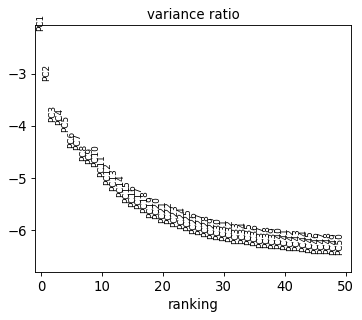

In [8]:
sc.pl.pca_variance_ratio(adata, log=True,n_pcs=50)

In [9]:
sorted_categories=[ 'Adult','Fetal',
    'NEr-fAOs','iPNECs','BTOs', 'dAOs/ALI']
adata.obs['Tissue'] = pd.Categorical(adata.obs['Tissue'], categories=sorted_categories)

In [10]:
adata.uns['Tissue_colors']=['#6A0572','#2EC4B6','#555555','#FFC300', '#FF5733', '#90EE90']
adata.uns['Tissue_colors']

['#6A0572', '#2EC4B6', '#555555', '#FFC300', '#FF5733', '#90EE90']

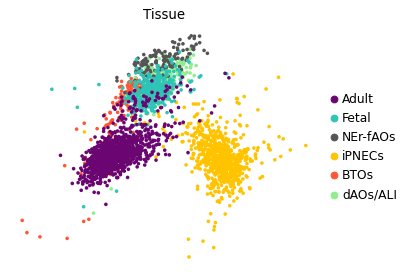

In [11]:
sc.pl.pca_scatter(adata, color=['Tissue'])

In [12]:
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=25)

In [67]:
sc.tl.draw_graph(adata)

In [68]:
sc.pl.draw_graph(adata, color=['Tissue'], save='_Alignment_Neuroendocrine_day10_NOT_harmonized_Tissue.png')

# HARMONY INTEGRATION

In [13]:
import numpy as np
import harmonypy as hm

x = adata.obsm["X_pca"].astype(np.float64)

ho = hm.run_harmony(
    x,
    adata.obs,
    ["Technique", "Sample ID"],
    max_iter_harmony=50,
)

# New harmonypy: already cells x PCs
adata.obsm["X_pca_harmony"] = ho.Z_corr

2026-06-29 15:33:12,746 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
INFO:harmonypy:Running Harmony (PyTorch on cuda)
2026-06-29 15:33:12,751 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-06-29 15:33:12,753 - harmonypy - INFO -     max_iter_harmony: 50
INFO:harmonypy:    max_iter_harmony: 50
2026-06-29 15:33:12,756 - harmonypy - INFO -     max_iter_kmeans: 20
INFO:harmonypy:    max_iter_kmeans: 20
2026-06-29 15:33:12,758 - harmonypy - INFO -     epsilon_cluster: 1e-05
INFO:harmonypy:    epsilon_cluster: 1e-05
2026-06-29 15:33:12,761 - harmonypy - INFO -     epsilon_harmony: 0.0001
INFO:harmonypy:    epsilon_harmony: 0.0001
2026-06-29 15:33:12,763 - harmonypy - INFO -     nclust: 95
INFO:harmonypy:    nclust: 95
2026-06-29 15:33:12,766 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-06-29 15:33:12,776 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 

(2839, 50)
2839


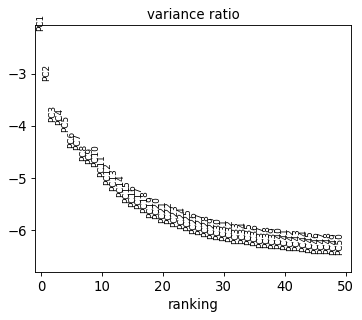

In [14]:
adata.obsm['prev_X_pca'] = adata.obsm['X_pca']
adata.obsm['X_pca'] = adata.obsm['X_pca_harmony']

sc.pl.pca_variance_ratio(adata, log=True,n_pcs=50)

In [15]:
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=25)

In [16]:
sc.tl.draw_graph(adata)

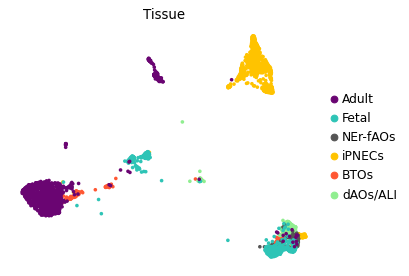

In [17]:
sc.pl.draw_graph(adata, color=['Tissue'], save='_Alignment_Neuroendocrine_day10_harmonized_tissue.png')

In [18]:
adata.write_h5ad('./../data/Merged_Neuroendocrine_annotated.h5ad',
    compression=hdf5plugin.FILTERS["zstd"],
    compression_opts=hdf5plugin.Zstd(clevel=5).filter_options
)

# DEG Tissue (Neuroendocrine Camonical Markers)
## Figure 4B

In [19]:
adata=sc.read_h5ad('./../data/Merged_Neuroendocrine_annotated.h5ad')
adata

AnnData object with n_obs × n_vars = 2839 × 25811
    obs: 'Sample ID', 'Patient ID', 'Tissue', 'Study', 'Time point', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'AT1', 'AT2', 'Basal', 'Bud Tip Adjacent', 'Bud Tip Progenitor', 'Club-like Secretory', 'Deuterosomal', 'Goblet', 'Goblet-like Secretory', 'Ionocyte', 'Lower Airway Progenitor', 'MEC', 'Mucous', 'Multiciliated', 'PNEC', 'RAS', 'SMG Basal/Duct', 'Secretory', 'Serous', 'Suprabasal', 'Tuft', 'Unknown', 'Reference', 'Technique', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cloneid', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.3', 'seurat_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'celltype', 'status', 'assignment', 'nCount_SCT', 'nFeature_SCT', 'sample_type', 'scHCL', 'scHCL_summary', 'scHCL_score', 'Age', 'Sex', 'Smoking_status', 'Last_smoking', 'Smoking_amount', 'Comorbidity', 'Specimen_Location', 'Clinical_diagnosis', 'Pathologic_diagnosis', 'integrated

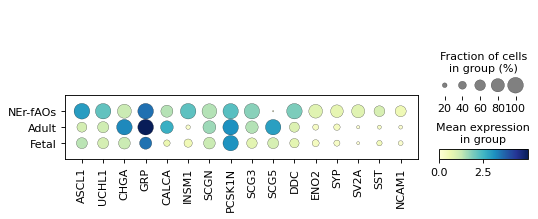

In [20]:
markers=['ASCL1','UCHL1','CHGA','GRP','CALCA','INSM1','SCGN', 'PCSK1N', 'SCG3', 'SCG5','DDC','ENO2','SYP','SV2A','SST','NCAM1']

adata_filtered = adata[adata.obs["Tissue"].isin(['NEr-fAOs', 'Adult', 'Fetal'])]
sc.pl.dotplot(adata_filtered, var_names=markers, groupby="Tissue", 
              categories_order=['NEr-fAOs', 'Adult', 'Fetal'],
              cmap=cmap, vmin=0,
             save='_Neuroendocrine_PNEC_markers_tissue')

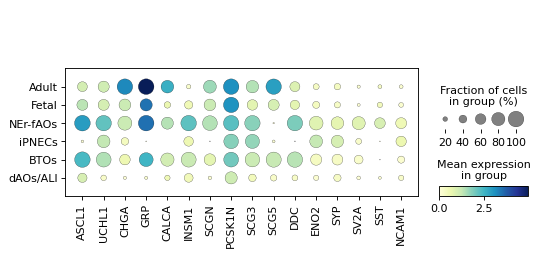

In [21]:
## Figure 4B
markers=['ASCL1','UCHL1','CHGA','GRP','CALCA','INSM1','SCGN', 'PCSK1N', 'SCG3', 'SCG5','DDC','ENO2','SYP','SV2A','SST','NCAM1']

sc.pl.dotplot(adata, var_names=markers, groupby='Tissue',cmap=cmap,vmin=0,save='_Neuroendocrine_PNEC_markers_models')

# Neuropeptide Combinations
## Figures 4D, S4B

In [33]:
adata=sc.read_h5ad('./../data/Merged_Neuroendocrine_annotated.h5ad')
adata

AnnData object with n_obs × n_vars = 2839 × 25811
    obs: 'Sample ID', 'Patient ID', 'Tissue', 'Study', 'Time point', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'AT1', 'AT2', 'Basal', 'Bud Tip Adjacent', 'Bud Tip Progenitor', 'Club-like Secretory', 'Deuterosomal', 'Goblet', 'Goblet-like Secretory', 'Ionocyte', 'Lower Airway Progenitor', 'MEC', 'Mucous', 'Multiciliated', 'PNEC', 'RAS', 'SMG Basal/Duct', 'Secretory', 'Serous', 'Suprabasal', 'Tuft', 'Unknown', 'Reference', 'Technique', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cloneid', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.3', 'seurat_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'celltype', 'status', 'assignment', 'nCount_SCT', 'nFeature_SCT', 'sample_type', 'scHCL', 'scHCL_summary', 'scHCL_score', 'Age', 'Sex', 'Smoking_status', 'Last_smoking', 'Smoking_amount', 'Comorbidity', 'Specimen_Location', 'Clinical_diagnosis', 'Pathologic_diagnosis', 'integrated

In [34]:
adata.layers['counts'] = adata.layers['counts']
adata.layers['CPM'] = adata.layers['counts']/adata.layers['counts'].sum()*1000000

In [35]:
neuropeptides = [
    #Peptidergic (Neuropeptides)
    'PCSK1N','GRP','CHGA',
    'CALCA', 'CCK', 'SST', 'ADCYAP1', 'ADM', 'AGRP', 'AGT',
    'CALCB', 'CARTPT', 'CHGB', 'CRH', 'DBI', 'EDN1', 'EDN3', 'GAL', 'GHRL', 
    'GNRH1', 'GNRH2', 'HCRT', 'IAPP', 'IGF1', 'IGF2', 'INHA', 'INHBA', 
    'INHBB', 'NMB', 'NPB', 'NPFF', 'NPPA', 'NPPB', 'NPPC', 
    'NPW', 'OXT', 'NPY',  'PNOC', 'POMC', 'SCG2', 
    'SCG3', 'SCG5', 'THPO', 'TRH', 'UCN', 'VGF',
    'TAC1','GHRH','PENK','OTP']
        
# Subset the expression matrix to these genes
adata_subset = adata[:, neuropeptides]

# Create a binary matrix where 1 means the gene is expressed (nonzero count)
expression_binary = (adata_subset.X.toarray() > 0).astype(int)
# Convert to dataframe for easy manipulation
expression_df = pd.DataFrame(expression_binary, index=adata.obs.index, columns=neuropeptides)

# Add tissue information
expression_df["Tissue"] = adata.obs["Tissue"].values

# Group by Tissue and sum across genes (to count how many neuropeptides are expressed per tissue)
neuropeptide_counts = expression_df.groupby("Tissue").sum()

# Count how many neuropeptide genes are expressed in each tissue (at least one cell expresses them)
neuropeptide_presence = (neuropeptide_counts > 0).sum(axis=1)

# Display the result
print(neuropeptide_presence)

Tissue
Adult       50
Fetal       49
NEr-fAOs    46
iPNECs      50
BTOs        49
dAOs/ALI    44
dtype: int64


/tmp/ipykernel_1872761/1183892971.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  neuropeptide_counts = expression_df.groupby("Tissue").sum()


In [36]:
# Binarize expression (1 = expressed, 0 = not expressed) using a threshold
threshold = 0  # Adjust based on your data
binary_matrix = (adata[:, neuropeptides].layers['counts'].toarray() > threshold).astype(int)

In [37]:
# Convert to DataFrame for easier manipulation
binary_df = pd.DataFrame(binary_matrix, index=adata.obs.index, columns=neuropeptides)

# Create a unique combination label for each cell
adata.obs["neuropeptide_combo"] = binary_df.apply(lambda row: "|".join(row.astype(str)), axis=1)


In [38]:
def label_combinations(row):
    expressed_genes = [gene for gene, expressed in zip(neuropeptides, row) if expressed]
    return "+".join(expressed_genes) if expressed_genes else "None"

In [39]:
adata.obs["neuropeptide_combo_named"] = binary_df.apply(label_combinations, axis=1)


In [40]:
# Check the unique combinations found
unique_combos = adata.obs["neuropeptide_combo_named"].value_counts()
print(unique_combos)

neuropeptide_combo_named
PCSK1N+DBI+IGF2+SCG3                           30
PCSK1N+IGF2+SCG3                               18
PCSK1N+CHGB+DBI+IGF2+SCG3                      16
PCSK1N+DBI                                     16
DBI                                            16
                                               ..
PCSK1N+DBI+GAL+IGF2+NPW+SCG3+TRH                1
PCSK1N+DBI+IGF2+NPW+SCG3                        1
PCSK1N+ADCYAP1+ADM+DBI+GHRL+IGF2+SCG3           1
PCSK1N+CHGA+SST+CALCB+CHGB+DBI+SCG3+UCN+VGF     1
PCSK1N+CHGA+CHGB+DBI+IGF2+NPB+SCG3+TRH          1
Name: count, Length: 2173, dtype: int64


In [41]:
# This counts how many distinct neuropeptide expression patterns exist per tissue.
combo_counts_per_tissue = adata.obs.groupby("Tissue")["neuropeptide_combo_named"].nunique()
print(combo_counts_per_tissue)

Tissue
Adult       948
Fetal       391
NEr-fAOs    117
iPNECs      517
BTOs        150
dAOs/ALI    100
Name: neuropeptide_combo_named, dtype: int64


/tmp/ipykernel_1872761/2331866051.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combo_counts_per_tissue = adata.obs.groupby("Tissue")["neuropeptide_combo_named"].nunique()


In [42]:
cell_counts_per_tissue = adata.obs["Tissue"].value_counts()
normalized_combo_counts = combo_counts_per_tissue / cell_counts_per_tissue
print(normalized_combo_counts)

Tissue
Adult       0.820779
Fetal       0.926540
NEr-fAOs    0.835714
iPNECs      0.657761
BTOs        0.914634
dAOs/ALI    0.581395
dtype: float64


In [43]:
# Convert the sparse matrix to a dense matrix
adata_dense = adata_subset.X.toarray()

# Sum the number of expressed neuropeptides per PNEC across genes (axis=1)
neuropeptide_counts_per_pnec = (adata_dense > 0).sum(axis=1)

# Flatten to ensure it's a 1D array
neuropeptide_counts_per_pnec = neuropeptide_counts_per_pnec.ravel()

# Check the shape of the result
print(neuropeptide_counts_per_pnec.shape)  # Should print (2200,)

tissue_info = adata_subset.obs["Tissue"].values

# Create the DataFrame
pnec_df = pd.DataFrame({
    "Neuropeptides_Expressed": neuropeptide_counts_per_pnec,
    "Tissue": tissue_info
})

# Display the first few rows of the DataFrame
print(pnec_df.head())

(2839,)
   Neuropeptides_Expressed  Tissue
0                        3  iPNECs
1                        5  iPNECs
2                       10  iPNECs
3                        6  iPNECs
4                        7  iPNECs


In [44]:
# Convert the sparse matrix to a dense matrix
adata_dense = adata_subset.X.toarray()

# Sum the number of expressed neuropeptides per PNEC across genes (axis=1)
neuropeptide_counts_per_pnec = (adata_dense > 0).sum(axis=1)

# Flatten to ensure it's a 1D array
neuropeptide_counts_per_pnec = neuropeptide_counts_per_pnec.ravel()

# Check the shape of the result
print(neuropeptide_counts_per_pnec.shape)  # Should print (2200,)

tissue_info = adata_subset.obs["Tissue"].values

# Create the DataFrame
pnec_df = pd.DataFrame({
    "Neuropeptides_Expressed": neuropeptide_counts_per_pnec,
    "Tissue": tissue_info
})

# Group by Tissue and calculate statistics
tissue_stats = pnec_df.groupby("Tissue")["Neuropeptides_Expressed"].agg(
    Mean="mean",
    Std_Dev="std",
    Min="min",
    Max="max"
)

# Add a Range column
tissue_stats["Range"] = tissue_stats["Max"] - tissue_stats["Min"]

# Display the result
print(tissue_stats)

(2839,)
               Mean   Std_Dev  Min  Max  Range
Tissue                                        
Adult     11.318615  3.179597    3   24     21
Fetal      7.812796  3.509813    0   33     33
NEr-fAOs  10.064286  3.315997    4   19     15
iPNECs     5.739186  4.356346    0   34     34
BTOs      10.207317  5.458685    1   24     23
dAOs/ALI   3.604651  2.704897    0   15     15


/tmp/ipykernel_1872761/1716608136.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_stats = pnec_df.groupby("Tissue")["Neuropeptides_Expressed"].agg(


/tmp/ipykernel_1872761/3142982424.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pnec_df, x="Tissue", y="Neuropeptides_Expressed", palette=['#6A0572','#2EC4B6','#555555','#FFC300', '#FF5733', '#90EE90'],
/tmp/ipykernel_1872761/3142982424.py:5: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.boxplot(data=pnec_df, x="Tissue", y="Neuropeptides_Expressed", palette=['#6A0572','#2EC4B6','#555555','#FFC300', '#FF5733', '#90EE90'],


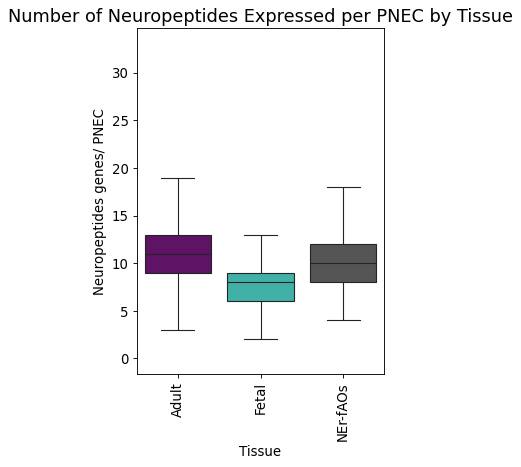

In [45]:
## Figure 4D

# Create the box plot with scatter points
plt.figure(figsize=(4,6))

# Create the box plot
sns.boxplot(data=pnec_df, x="Tissue", y="Neuropeptides_Expressed", palette=['#6A0572','#2EC4B6','#555555','#FFC300', '#FF5733', '#90EE90'],
            order=['Adult', 'Fetal', 'NEr-fAOs'],
            fliersize=0)

# Customize plot appearance
plt.title("Number of Neuropeptides Expressed per PNEC by Tissue",fontsize=16)
plt.xlabel("Tissue",fontsize=12)
plt.ylabel("Neuropeptides genes/ PNEC", fontsize=12)

# Show the plot
plt.xticks(rotation=90,fontsize=12)  # Rotate x-axis labels for better visibility
plt.tight_layout()

plt.savefig(os.path.join(figfolder, "Alignment_Neuroendocrine_day10_n_neuropeptides_tissue.png"),
                            bbox_inches='tight', pad_inches=0.1)
plt.show()
                

/tmp/ipykernel_1872761/2323120501.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pnec_df, x="Tissue", y="Neuropeptides_Expressed", palette=['#6A0572','#2EC4B6','#555555','#FFC300', '#FF5733', '#90EE90'],


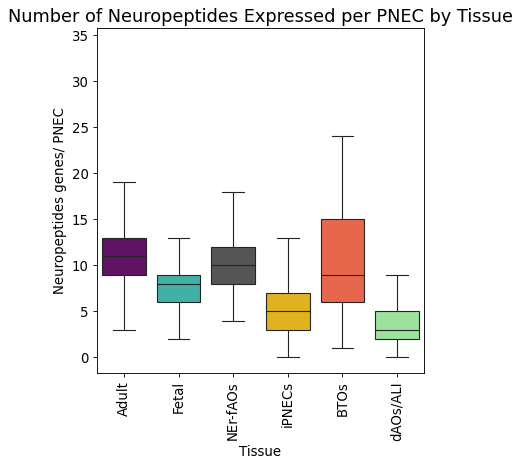

In [47]:
## Figure S4B

# Create the box plot with scatter points
plt.figure(figsize=(5, 6))

# Create the box plot
sns.boxplot(data=pnec_df, x="Tissue", y="Neuropeptides_Expressed", palette=['#6A0572','#2EC4B6','#555555','#FFC300', '#FF5733', '#90EE90'],
            fliersize=0)

# Customize plot appearance
plt.title("Number of Neuropeptides Expressed per PNEC by Tissue",fontsize=16)
plt.xlabel("Tissue",fontsize=12)
plt.ylabel("Neuropeptides genes/ PNEC",fontsize=12)

# Show the plot
plt.xticks(rotation=90,fontsize=12)  # Rotate x-axis labels for better visibility
plt.tight_layout()

plt.savefig(os.path.join(figfolder, "Alignment_Neuroendocrine_day10_n_neuropeptides_models.png"),
                            bbox_inches='tight', pad_inches=0.1)
plt.show()
                

# Barplot - Neuroendocrine Genes 
## Figures 4E-F, S4C-D

In [3]:
adata=sc.read_h5ad('./../data/Merged_Neuroendocrine_annotated.h5ad')
adata

AnnData object with n_obs × n_vars = 2838 × 25813
    obs: 'Sample ID', 'Patient ID', 'Tissue', 'Study', 'Time point', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'AT1', 'AT2', 'Basal', 'Bud Tip Adjacent', 'Bud Tip Progenitor', 'Club-like Secretory', 'Deuterosomal', 'Goblet', 'Goblet-like Secretory', 'Ionocyte', 'Lower Airway Progenitor', 'MEC', 'Mucous', 'Multiciliated', 'PNEC', 'RAS', 'SMG Basal/Duct', 'Secretory', 'Serous', 'Suprabasal', 'Tuft', 'Unknown', 'Reference', 'Technique', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cloneid', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.3', 'seurat_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'celltype', 'status', 'assignment', 'nCount_SCT', 'nFeature_SCT', 'sample_type', 'scHCL', 'scHCL_summary', 'scHCL_score', 'Age', 'Sex', 'Smoking_status', 'Last_smoking', 'Smoking_amount', 'Comorbidity', 'Specimen_Location', 'Clinical_diagnosis', 'Pathologic_diagnosis', 'integrated

In [4]:
adata.layers['counts'] = adata.layers['counts']
adata.layers['CPM'] = adata.layers['counts']/adata.layers['counts'].sum()*1000000

In [5]:
neuroendocrinology_genes=[
    #Peptidergic
       'PCSK1N', 'GRP', 'CHGA', 'DBI', 'SCG3', 'SCG2',  'CHGB', 'SCG5',
       'CALCA', 'INHBA',  'INHBB', 'SST', 'NPW', 'GHRL', 'POMC',
       'VGF', 'NPPA', 'OTP',  'NMB', 'ADM',  'TRH', 'IGF1',
       'IGF2', 'CALCB', 'AGRP', 'TAC1', 'ADCYAP1', 'EDN1', 'PNOC', 'HCRT',
       'AGT', 'CRH', 'INHA',  'GAL',  'NPFF', 'GNRH1', 'CARTPT',
       'NPB', 'PENK', 'EDN3', 'NPPC', 'GNRH2', 'NPY',  'UCN', 'THPO',
        'NPPB', 'IAPP', 'OXT', 'CCK',  'GHRH',
    #Neuroetransmitters
    'DDC','TPH1', 'GLS','GAD1','GLS2','DBH','PNMT','HDC','GAD2','TPH2', 'TH']

In [6]:
mask = adata.obs['Tissue'].isin(['Fetal'])
adata_fetal = adata[mask]
adata_fetal

View of AnnData object with n_obs × n_vars = 422 × 25813
    obs: 'Sample ID', 'Patient ID', 'Tissue', 'Study', 'Time point', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'AT1', 'AT2', 'Basal', 'Bud Tip Adjacent', 'Bud Tip Progenitor', 'Club-like Secretory', 'Deuterosomal', 'Goblet', 'Goblet-like Secretory', 'Ionocyte', 'Lower Airway Progenitor', 'MEC', 'Mucous', 'Multiciliated', 'PNEC', 'RAS', 'SMG Basal/Duct', 'Secretory', 'Serous', 'Suprabasal', 'Tuft', 'Unknown', 'Reference', 'Technique', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cloneid', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.3', 'seurat_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'celltype', 'status', 'assignment', 'nCount_SCT', 'nFeature_SCT', 'sample_type', 'scHCL', 'scHCL_summary', 'scHCL_score', 'Age', 'Sex', 'Smoking_status', 'Last_smoking', 'Smoking_amount', 'Comorbidity', 'Specimen_Location', 'Clinical_diagnosis', 'Pathologic_diagnosis', 'int

In [7]:
mask = adata.obs['Tissue'].isin(['Adult'])
adata_adult = adata[mask]
adata_adult

View of AnnData object with n_obs × n_vars = 1155 × 25813
    obs: 'Sample ID', 'Patient ID', 'Tissue', 'Study', 'Time point', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'AT1', 'AT2', 'Basal', 'Bud Tip Adjacent', 'Bud Tip Progenitor', 'Club-like Secretory', 'Deuterosomal', 'Goblet', 'Goblet-like Secretory', 'Ionocyte', 'Lower Airway Progenitor', 'MEC', 'Mucous', 'Multiciliated', 'PNEC', 'RAS', 'SMG Basal/Duct', 'Secretory', 'Serous', 'Suprabasal', 'Tuft', 'Unknown', 'Reference', 'Technique', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cloneid', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.3', 'seurat_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'celltype', 'status', 'assignment', 'nCount_SCT', 'nFeature_SCT', 'sample_type', 'scHCL', 'scHCL_summary', 'scHCL_score', 'Age', 'Sex', 'Smoking_status', 'Last_smoking', 'Smoking_amount', 'Comorbidity', 'Specimen_Location', 'Clinical_diagnosis', 'Pathologic_diagnosis', 'in

In [8]:
mask = adata.obs['Tissue'].isin(['NEr-fAOs'])
adata_dayton = adata[mask]
adata_dayton

View of AnnData object with n_obs × n_vars = 140 × 25813
    obs: 'Sample ID', 'Patient ID', 'Tissue', 'Study', 'Time point', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'AT1', 'AT2', 'Basal', 'Bud Tip Adjacent', 'Bud Tip Progenitor', 'Club-like Secretory', 'Deuterosomal', 'Goblet', 'Goblet-like Secretory', 'Ionocyte', 'Lower Airway Progenitor', 'MEC', 'Mucous', 'Multiciliated', 'PNEC', 'RAS', 'SMG Basal/Duct', 'Secretory', 'Serous', 'Suprabasal', 'Tuft', 'Unknown', 'Reference', 'Technique', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cloneid', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.3', 'seurat_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'celltype', 'status', 'assignment', 'nCount_SCT', 'nFeature_SCT', 'sample_type', 'scHCL', 'scHCL_summary', 'scHCL_score', 'Age', 'Sex', 'Smoking_status', 'Last_smoking', 'Smoking_amount', 'Comorbidity', 'Specimen_Location', 'Clinical_diagnosis', 'Pathologic_diagnosis', 'int

In [9]:
mask = adata.obs['Tissue'].isin(['dAOs/ALI'])
adata_lee = adata[mask]
adata_lee

View of AnnData object with n_obs × n_vars = 171 × 25813
    obs: 'Sample ID', 'Patient ID', 'Tissue', 'Study', 'Time point', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'AT1', 'AT2', 'Basal', 'Bud Tip Adjacent', 'Bud Tip Progenitor', 'Club-like Secretory', 'Deuterosomal', 'Goblet', 'Goblet-like Secretory', 'Ionocyte', 'Lower Airway Progenitor', 'MEC', 'Mucous', 'Multiciliated', 'PNEC', 'RAS', 'SMG Basal/Duct', 'Secretory', 'Serous', 'Suprabasal', 'Tuft', 'Unknown', 'Reference', 'Technique', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cloneid', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.3', 'seurat_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'celltype', 'status', 'assignment', 'nCount_SCT', 'nFeature_SCT', 'sample_type', 'scHCL', 'scHCL_summary', 'scHCL_score', 'Age', 'Sex', 'Smoking_status', 'Last_smoking', 'Smoking_amount', 'Comorbidity', 'Specimen_Location', 'Clinical_diagnosis', 'Pathologic_diagnosis', 'int

In [10]:
mask = adata.obs['Tissue'].isin(['BTOs'])
adata_conchola_organoid = adata[mask]
adata_conchola_organoid

View of AnnData object with n_obs × n_vars = 164 × 25813
    obs: 'Sample ID', 'Patient ID', 'Tissue', 'Study', 'Time point', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'AT1', 'AT2', 'Basal', 'Bud Tip Adjacent', 'Bud Tip Progenitor', 'Club-like Secretory', 'Deuterosomal', 'Goblet', 'Goblet-like Secretory', 'Ionocyte', 'Lower Airway Progenitor', 'MEC', 'Mucous', 'Multiciliated', 'PNEC', 'RAS', 'SMG Basal/Duct', 'Secretory', 'Serous', 'Suprabasal', 'Tuft', 'Unknown', 'Reference', 'Technique', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cloneid', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.3', 'seurat_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'celltype', 'status', 'assignment', 'nCount_SCT', 'nFeature_SCT', 'sample_type', 'scHCL', 'scHCL_summary', 'scHCL_score', 'Age', 'Sex', 'Smoking_status', 'Last_smoking', 'Smoking_amount', 'Comorbidity', 'Specimen_Location', 'Clinical_diagnosis', 'Pathologic_diagnosis', 'int

In [11]:
mask = adata.obs['Tissue'].isin(['iPNECs'])
adata_iPNECs = adata[mask]
adata_iPNECs

View of AnnData object with n_obs × n_vars = 786 × 25813
    obs: 'Sample ID', 'Patient ID', 'Tissue', 'Study', 'Time point', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'AT1', 'AT2', 'Basal', 'Bud Tip Adjacent', 'Bud Tip Progenitor', 'Club-like Secretory', 'Deuterosomal', 'Goblet', 'Goblet-like Secretory', 'Ionocyte', 'Lower Airway Progenitor', 'MEC', 'Mucous', 'Multiciliated', 'PNEC', 'RAS', 'SMG Basal/Duct', 'Secretory', 'Serous', 'Suprabasal', 'Tuft', 'Unknown', 'Reference', 'Technique', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cloneid', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.3', 'seurat_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'celltype', 'status', 'assignment', 'nCount_SCT', 'nFeature_SCT', 'sample_type', 'scHCL', 'scHCL_summary', 'scHCL_score', 'Age', 'Sex', 'Smoking_status', 'Last_smoking', 'Smoking_amount', 'Comorbidity', 'Specimen_Location', 'Clinical_diagnosis', 'Pathologic_diagnosis', 'int

In [12]:
dfs_NE = {}

for gene in neuroendocrinology_genes:

    if gene not in adata.var_names:
        continue

    adult_mask = adata_adult[:, adata_adult.var_names == gene].layers['CPM'] > 0
    adult_pos = adata_adult[adult_mask]
    gene_index_adult = adult_pos.var_names.get_loc(gene)
    mean_expression_adult = adult_pos.layers['CPM'][:, gene_index_adult].mean()+1

    fetal_mask = adata_fetal[:, adata_fetal.var_names == gene].layers['CPM'] > 0
    fetal_pos = adata_fetal[fetal_mask]
    gene_index_fetal = fetal_pos.var_names.get_loc(gene)
    mean_expression_fetal = fetal_pos.layers['CPM'][:, gene_index_fetal].mean()+1
    
    dayton_mask = adata_dayton[:, adata_dayton.var_names == gene].layers['CPM'] > 0
    dayton_pos = adata_dayton[dayton_mask]
    gene_index_dayton = dayton_pos.var_names.get_loc(gene)
    mean_expression_dayton = dayton_pos.layers['CPM'][:, gene_index_dayton].mean()+1

    iPNECs_mask = adata_iPNECs[:, adata_iPNECs.var_names == gene].layers['CPM'] > 0
    iPNECs_pos = adata_iPNECs[iPNECs_mask]
    gene_index_iPNECs = iPNECs_pos.var_names.get_loc(gene)
    mean_expression_iPNECs = iPNECs_pos.layers['CPM'][:, gene_index_iPNECs].mean()+1

    conchola_organoid_mask = adata_conchola_organoid[:, adata_conchola_organoid.var_names == gene].layers['CPM'] > 0
    conchola_organoid_pos = adata_conchola_organoid[conchola_organoid_mask]
    gene_index_conchola_organoid = conchola_organoid_pos.var_names.get_loc(gene)
    mean_expression_conchola_organoid = conchola_organoid_pos.layers['CPM'][:, gene_index_conchola_organoid].mean()+1
    
    lee_mask = adata_lee[:, adata_lee.var_names == gene].layers['CPM'] > 0
    lee_pos = adata_lee[lee_mask]
    gene_index_lee = lee_pos.var_names.get_loc(gene)
    mean_expression_lee = lee_pos.layers['CPM'][:, gene_index_lee].mean()+1

    
    neg_mask = adata[:, adata.var_names == gene].layers['CPM'] == 0
    neg = adata[neg_mask]
    
    df_gene = {
        'Adult': len(adult_pos.obs_names),
        'Fetal': len(fetal_pos.obs_names),
        'NEr-fAOs': len(dayton_pos.obs_names),
        'iPNECs': len(iPNECs_pos.obs_names),
        'BTOs': len(conchola_organoid_pos.obs_names),
        'dAOs/ALI': len(lee_pos.obs_names),

        'Total NE cell (Adult)': len(adata_adult.obs_names),
        'Total NE cell (Fetal)': len(adata_fetal.obs_names),
        'Total NE cell (NEr-fAOs)': len(adata_dayton.obs_names),
        'Total NE cell (iPNECs)': len(adata_iPNECs.obs_names),
        'Total NE cell (BTOs)': len(adata_conchola_organoid.obs_names),
        'Total NE cell (dAOs/ALI)': len(adata_lee.obs_names),

        'Counts Adult': mean_expression_adult,       
        'Counts Fetal': mean_expression_fetal,
        'Counts NEr-fAOs': mean_expression_dayton,
        'Counts iPNECs': mean_expression_iPNECs,       
        'Counts BTOs': mean_expression_conchola_organoid,
        'Counts dAOs/ALI': mean_expression_lee,

    }
    
    dfs_NE[gene] = df_gene


In [13]:
dfs_NE

{'PCSK1N': {'Adult': 1138,
  'Fetal': 411,
  'NEr-fAOs': 136,
  'iPNECs': 716,
  'BTOs': 152,
  'dAOs/ALI': 123,
  'Total NE cell (Adult)': 1155,
  'Total NE cell (Fetal)': 422,
  'Total NE cell (NEr-fAOs)': 140,
  'Total NE cell (iPNECs)': 786,
  'Total NE cell (BTOs)': 164,
  'Total NE cell (dAOs/ALI)': 171,
  'Counts Adult': 1.6027922726710662,
  'Counts Fetal': 1.71012080906741,
  'Counts NEr-fAOs': 1.589671309325594,
  'Counts iPNECs': 1.2913504672379537,
  'Counts BTOs': 1.950007344113999,
  'Counts dAOs/ALI': 1.2976130570885713},
 'GRP': {'Adult': 1149,
  'Fetal': 301,
  'NEr-fAOs': 139,
  'iPNECs': 16,
  'BTOs': 140,
  'dAOs/ALI': 18,
  'Total NE cell (Adult)': 1155,
  'Total NE cell (Fetal)': 422,
  'Total NE cell (NEr-fAOs)': 140,
  'Total NE cell (iPNECs)': 786,
  'Total NE cell (BTOs)': 164,
  'Total NE cell (dAOs/ALI)': 171,
  'Counts Adult': 4.538942157432774,
  'Counts Fetal': 6.255429483963409,
  'Counts NEr-fAOs': 3.1359731204291554,
  'Counts iPNECs': 1.06455700836253

In [14]:
df_NE=pd.DataFrame.from_dict(dfs_NE, orient='index')
df_NE

,Adult,Fetal,NEr-fAOs,iPNECs,BTOs,dAOs/ALI,Total NE cell (Adult),Total NE cell (Fetal),Total NE cell (NEr-fAOs),Total NE cell (iPNECs),Total NE cell (BTOs),Total NE cell (dAOs/ALI),Counts Adult,Counts Fetal,Counts NEr-fAOs,Counts iPNECs,Counts BTOs,Counts dAOs/ALI
PCSK1N,1138,411,136,716,152,123,1155,422,140,786,164,171,1.602792,1.710121,1.589671,1.291350,1.950007,1.297613
GRP,1149,301,139,16,140,18,1155,422,140,786,164,171,4.538942,6.255429,3.135973,1.064557,4.046796,1.504979
CHGA,1136,287,120,297,97,21,1155,422,140,786,164,171,1.540279,1.228896,1.198663,1.079572,1.284104,1.072796
DBI,706,253,119,502,161,166,1155,422,140,786,164,171,1.090768,1.102230,1.132629,1.091522,1.578174,1.256610
SCG3,853,247,136,686,149,64,1155,422,140,786,164,171,1.172870,1.082968,1.348760,1.299876,1.300030,1.146544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PNMT,8,12,2,82,9,2,1155,422,140,786,164,171,1.041316,1.044760,1.041316,1.056936,1.041316,1.041316
HDC,0,5,0,1,0,0,1155,422,140,786,164,171,1.000000,1.049580,1.000000,1.041316,1.000000,1.000000
GAD2,4,4,0,26,2,0,1155,422,140,786,164,171,1.061975,1.041316,1.000000,1.069920,1.144608,1.000000
TPH2,0,0,0,5,2,0,1155,422,140,786,164,171,1.000000,1.000000,1.000000,1.041316,1.041316,1.000000


In [15]:
df_NE_perc_sorted=df_NE.copy()

df_NE_perc_sorted['Adult']=df_NE['Adult']/df_NE['Total NE cell (Adult)']*100
df_NE_perc_sorted['Fetal']=df_NE['Fetal']/df_NE['Total NE cell (Fetal)']*100
df_NE_perc_sorted['NEr-fAOs']=df_NE['NEr-fAOs']/df_NE['Total NE cell (NEr-fAOs)']*100
df_NE_perc_sorted['iPNECs']=df_NE['iPNECs']/df_NE['Total NE cell (iPNECs)']*100
df_NE_perc_sorted['BTOs']=df_NE['BTOs']/df_NE['Total NE cell (BTOs)']*100
df_NE_perc_sorted['dAOs/ALI']=df_NE['dAOs/ALI']/df_NE['Total NE cell (dAOs/ALI)']*100

df_NE_perc_sorted['Counts Adult'] = df_NE_perc_sorted['Counts Adult'].round(1)
df_NE_perc_sorted['Counts Fetal'] = df_NE_perc_sorted['Counts Fetal'].round(1)
df_NE_perc_sorted['Counts NEr-fAOs'] = df_NE_perc_sorted['Counts NEr-fAOs'].round(1)
df_NE_perc_sorted['Counts iPNECs'] = df_NE_perc_sorted['Counts iPNECs'].round(1)
df_NE_perc_sorted['Counts BTOs'] = df_NE_perc_sorted['Counts BTOs'].round(1)
df_NE_perc_sorted['Counts dAOs/ALI'] = df_NE_perc_sorted['Counts dAOs/ALI'].round(1)

df_NE_perc_sorted['Sorting']=df_NE['Adult']+df_NE['Fetal']+df_NE['NEr-fAOs']
df_NE_perc_sorted = df_NE_perc_sorted.sort_values(by='Sorting', ascending=False)
df_NE_perc_sorted

,Adult,Fetal,NEr-fAOs,iPNECs,BTOs,dAOs/ALI,Total NE cell (Adult),Total NE cell (Fetal),Total NE cell (NEr-fAOs),Total NE cell (iPNECs),Total NE cell (BTOs),Total NE cell (dAOs/ALI),Counts Adult,Counts Fetal,Counts NEr-fAOs,Counts iPNECs,Counts BTOs,Counts dAOs/ALI,Sorting
PCSK1N,98.528139,97.393365,97.142857,91.094148,92.682927,71.929825,1155,422,140,786,164,171,1.6,1.7,1.6,1.3,2.0,1.3,1685
GRP,99.480519,71.327014,99.285714,2.035623,85.365854,10.526316,1155,422,140,786,164,171,4.5,6.3,3.1,1.1,4.0,1.5,1589
CHGA,98.354978,68.009479,85.714286,37.786260,59.146341,12.280702,1155,422,140,786,164,171,1.5,1.2,1.2,1.1,1.3,1.1,1543
SCG5,97.575758,62.322275,4.285714,9.923664,95.121951,30.994152,1155,422,140,786,164,171,1.4,1.1,1.0,1.1,1.3,1.1,1396
SCG3,73.852814,58.530806,97.142857,87.277354,90.853659,37.426901,1155,422,140,786,164,171,1.2,1.1,1.3,1.3,1.3,1.1,1236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PNOC,0.000000,0.710900,0.000000,0.000000,0.609756,0.000000,1155,422,140,786,164,171,1.0,1.1,1.0,1.0,1.0,1.0,3
OXT,0.173160,0.236967,0.000000,0.127226,0.609756,0.000000,1155,422,140,786,164,171,1.0,1.0,1.0,1.0,1.0,1.0,3
IAPP,0.086580,0.000000,0.000000,0.890585,0.000000,0.000000,1155,422,140,786,164,171,1.0,1.0,1.0,1.0,1.0,1.0,1
TH,0.000000,0.236967,0.000000,12.849873,0.000000,0.000000,1155,422,140,786,164,171,1.0,1.0,1.0,1.1,1.0,1.0,1


In [16]:
df_NE_perc=df_NE.copy()

df_NE_perc['Adult']=df_NE['Adult']/df_NE['Total NE cell (Adult)']*100
df_NE_perc['Fetal']=df_NE['Fetal']/df_NE['Total NE cell (Fetal)']*100
df_NE_perc['NEr-fAOs']=df_NE['NEr-fAOs']/df_NE['Total NE cell (NEr-fAOs)']*100
df_NE_perc['iPNECs']=df_NE['iPNECs']/df_NE['Total NE cell (iPNECs)']*100
df_NE_perc['BTOs']=df_NE['BTOs']/df_NE['Total NE cell (BTOs)']*100
df_NE_perc['dAOs/ALI']=df_NE['dAOs/ALI']/df_NE['Total NE cell (dAOs/ALI)']*100

df_NE_perc['Counts Adult'] = df_NE_perc['Counts Adult'].round(1)
df_NE_perc['Counts Fetal'] = df_NE_perc['Counts Fetal'].round(1)
df_NE_perc['Counts NEr-fAOs'] = df_NE_perc['Counts NEr-fAOs'].round(1)
df_NE_perc['Counts iPNECs'] = df_NE_perc['Counts iPNECs'].round(1)
df_NE_perc['Counts BTOs'] = df_NE_perc['Counts BTOs'].round(1)
df_NE_perc['Counts dAOs/ALI'] = df_NE_perc['Counts dAOs/ALI'].round(1)
df_NE_perc

,Adult,Fetal,NEr-fAOs,iPNECs,BTOs,dAOs/ALI,Total NE cell (Adult),Total NE cell (Fetal),Total NE cell (NEr-fAOs),Total NE cell (iPNECs),Total NE cell (BTOs),Total NE cell (dAOs/ALI),Counts Adult,Counts Fetal,Counts NEr-fAOs,Counts iPNECs,Counts BTOs,Counts dAOs/ALI
PCSK1N,98.528139,97.393365,97.142857,91.094148,92.682927,71.929825,1155,422,140,786,164,171,1.6,1.7,1.6,1.3,2.0,1.3
GRP,99.480519,71.327014,99.285714,2.035623,85.365854,10.526316,1155,422,140,786,164,171,4.5,6.3,3.1,1.1,4.0,1.5
CHGA,98.354978,68.009479,85.714286,37.786260,59.146341,12.280702,1155,422,140,786,164,171,1.5,1.2,1.2,1.1,1.3,1.1
DBI,61.125541,59.952607,85.000000,63.867684,98.170732,97.076023,1155,422,140,786,164,171,1.1,1.1,1.1,1.1,1.6,1.3
SCG3,73.852814,58.530806,97.142857,87.277354,90.853659,37.426901,1155,422,140,786,164,171,1.2,1.1,1.3,1.3,1.3,1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PNMT,0.692641,2.843602,1.428571,10.432570,5.487805,1.169591,1155,422,140,786,164,171,1.0,1.0,1.0,1.1,1.0,1.0
HDC,0.000000,1.184834,0.000000,0.127226,0.000000,0.000000,1155,422,140,786,164,171,1.0,1.0,1.0,1.0,1.0,1.0
GAD2,0.346320,0.947867,0.000000,3.307888,1.219512,0.000000,1155,422,140,786,164,171,1.1,1.0,1.0,1.1,1.1,1.0
TPH2,0.000000,0.000000,0.000000,0.636132,1.219512,0.000000,1155,422,140,786,164,171,1.0,1.0,1.0,1.0,1.0,1.0


In [17]:
## Figures 4F, S4D

df_NE_perc_filtered = df_NE_perc_sorted[
(df_NE_perc_sorted['Adult'] < 5) &
    (df_NE_perc_sorted['Fetal'] < 5) &
    (df_NE_perc_sorted['NEr-fAOs'] < 5)]

df_NE_perc_filtered
df_NE_perc_filtered.to_csv("./../data/markers/df_NE_filtered.csv", index=True)
df_NE_perc_filtered

,Adult,Fetal,NEr-fAOs,iPNECs,BTOs,dAOs/ALI,Total NE cell (Adult),Total NE cell (Fetal),Total NE cell (NEr-fAOs),Total NE cell (iPNECs),Total NE cell (BTOs),Total NE cell (dAOs/ALI),Counts Adult,Counts Fetal,Counts NEr-fAOs,Counts iPNECs,Counts BTOs,Counts dAOs/ALI,Sorting
HCRT,2.510823,3.080569,1.428571,2.162850,12.804878,1.169591,1155,422,140,786,164,171,1.0,1.0,1.1,1.0,1.1,1.0,44
CARTPT,3.463203,0.000000,0.000000,0.127226,0.000000,0.000000,1155,422,140,786,164,171,1.5,1.0,1.0,1.0,1.0,1.0,40
DBH,2.251082,1.421801,1.428571,0.763359,1.219512,1.754386,1155,422,140,786,164,171,1.1,1.0,1.0,1.0,1.0,1.0,34
IGF1,1.038961,4.739336,0.714286,4.580153,0.000000,15.789474,1155,422,140,786,164,171,1.0,1.1,1.0,1.1,1.0,1.1,33
CRH,0.952381,4.265403,0.714286,0.000000,2.439024,0.584795,1155,422,140,786,164,171,1.0,1.1,1.0,1.0,1.1,1.0,30
EDN1,1.298701,1.895735,2.857143,3.562341,3.048780,1.754386,1155,422,140,786,164,171,1.0,1.1,1.0,1.1,1.0,1.2,27
PENK,1.298701,1.895735,1.428571,3.180662,0.609756,0.000000,1155,422,140,786,164,171,1.1,1.3,1.0,1.0,1.0,1.0,25
PNMT,0.692641,2.843602,1.428571,10.432570,5.487805,1.169591,1155,422,140,786,164,171,1.0,1.0,1.0,1.1,1.0,1.0,22
INHA,0.432900,1.658768,2.142857,1.399491,6.097561,0.000000,1155,422,140,786,164,171,1.0,1.0,1.0,1.0,1.0,1.0,15
GHRH,1.125541,0.473934,0.000000,1.781170,0.000000,0.000000,1155,422,140,786,164,171,1.1,1.1,1.0,1.1,1.0,1.0,15


In [18]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

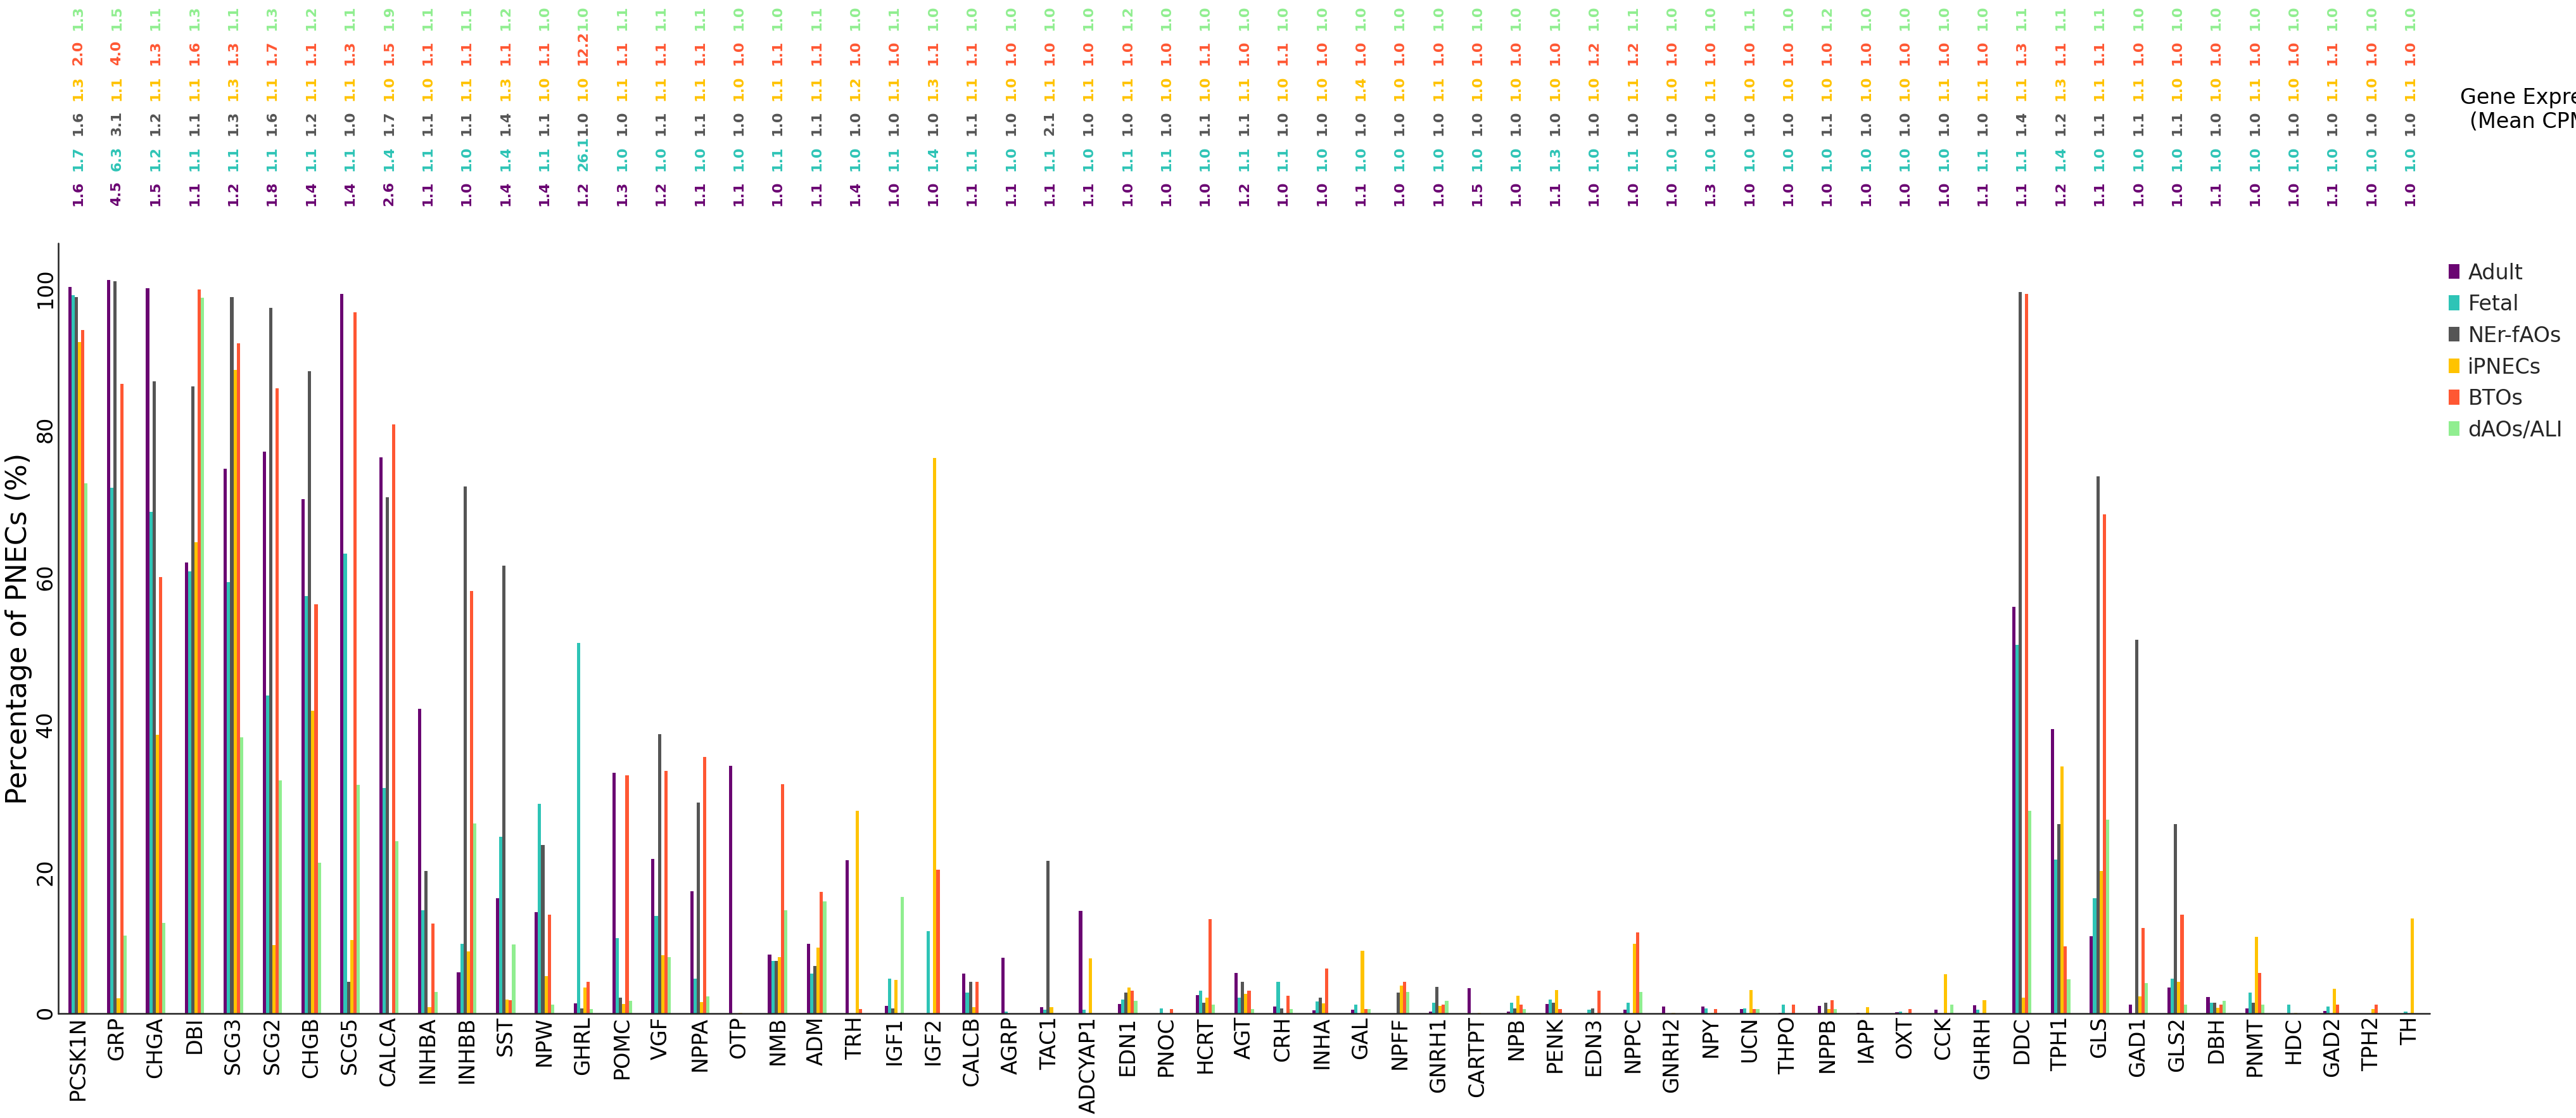

In [24]:
# Set the figure size and style based on your preference
plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(60, 20))

# Use the bar function to create a stacked bar plot
df_plot = df_NE_perc[['Adult','Fetal','NEr-fAOs',
                     'iPNECs','BTOs','dAOs/ALI']]

df_plot.plot(kind='bar', stacked=False, color=['#6A0572','#2EC4B6','#555555','#FFC300', '#FF5733', '#90EE90'],
             edgecolor=None,width=0.5, ax=ax)

# Customize the plot
plt.grid(False)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=30)
plt.yticks(size=30,color='black',rotation=90)
plt.xticks(rotation=90, size=30, color='black')
plt.ylabel("Percentage of PNECs (%)", size = 40, color='black')

# Add another axis on top with corresponding ticks and values
ax_adult = ax.twiny()
ax_adult.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_adult.set_xticks(ax.get_xticks())  # Set the positions of the ticks
ax_adult.spines['top'].set_position(('outward', 50))
ax_adult.set_xticklabels(df_NE_perc['Counts Adult'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#6A0572')

ax_fetal = ax.twiny()
ax_fetal.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_fetal.set_xticks(ax.get_xticks())  # Set the positions of the ticks
ax_fetal.spines['top'].set_position(('outward', 100))
ax_fetal.set_xticklabels(df_NE_perc['Counts Fetal'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#2EC4B6')

ax_dayton = ax.twiny()
ax_dayton.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_dayton.set_xticks(ax.get_xticks()) # Set the positions of the ticks
ax_dayton.spines['top'].set_position(('outward', 150))
ax_dayton.set_xticklabels(df_NE_perc['Counts NEr-fAOs'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#555555')
ax_dayton.xaxis.set_label_coords(1.05, 1.05)  # Adjust the label position

ax_iPNECs = ax.twiny()
ax_iPNECs.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_iPNECs.set_xticks(ax.get_xticks())  # Set the positions of the ticks
ax_iPNECs.spines['top'].set_position(('outward', 200))
ax_iPNECs.set_xticklabels(df_NE_perc['Counts iPNECs'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#FFC300')

ax_conchola_organoid = ax.twiny()
ax_conchola_organoid.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_conchola_organoid.set_xticks(ax.get_xticks())  # Set the positions of the ticks
ax_conchola_organoid.spines['top'].set_position(('outward', 250))
ax_conchola_organoid.set_xticklabels(df_NE_perc['Counts BTOs'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#FF5733')

ax_lee = ax.twiny()
ax_lee.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_lee.set_xticks(ax.get_xticks()) # Set the positions of the ticks
ax_lee.spines['top'].set_position(('outward', 300))
ax_lee.set_xticklabels(df_NE_perc['Counts dAOs/ALI'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#90EE90')

ax_lee.set_xlabel("Gene Expression\n(Mean CPM+1)", size=30, color='black')
ax_lee.xaxis.set_label_coords(1.05, 1.15)  # Adjust the label position

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax_adult.spines['top'].set_visible(False)
ax_fetal.spines['top'].set_visible(False)
ax_dayton.spines['top'].set_visible(False)
ax_iPNECs.spines['top'].set_visible(False)
ax_conchola_organoid.spines['top'].set_visible(False)
ax_lee.spines['top'].set_visible(False)
ax_adult.spines['right'].set_visible(False)
ax_fetal.spines['right'].set_visible(False)
ax_dayton.spines['right'].set_visible(False)
ax_iPNECs.spines['right'].set_visible(False)
ax_conchola_organoid.spines['right'].set_visible(False)
ax_lee.spines['right'].set_visible(False)

plt.savefig(os.path.join(figfolder,'BarPlot_Alignment_Neuroendocrine_day10_all_NE_genes.pdf'),
            bbox_inches='tight', pad_inches=2)

# Show the plot
plt.show()

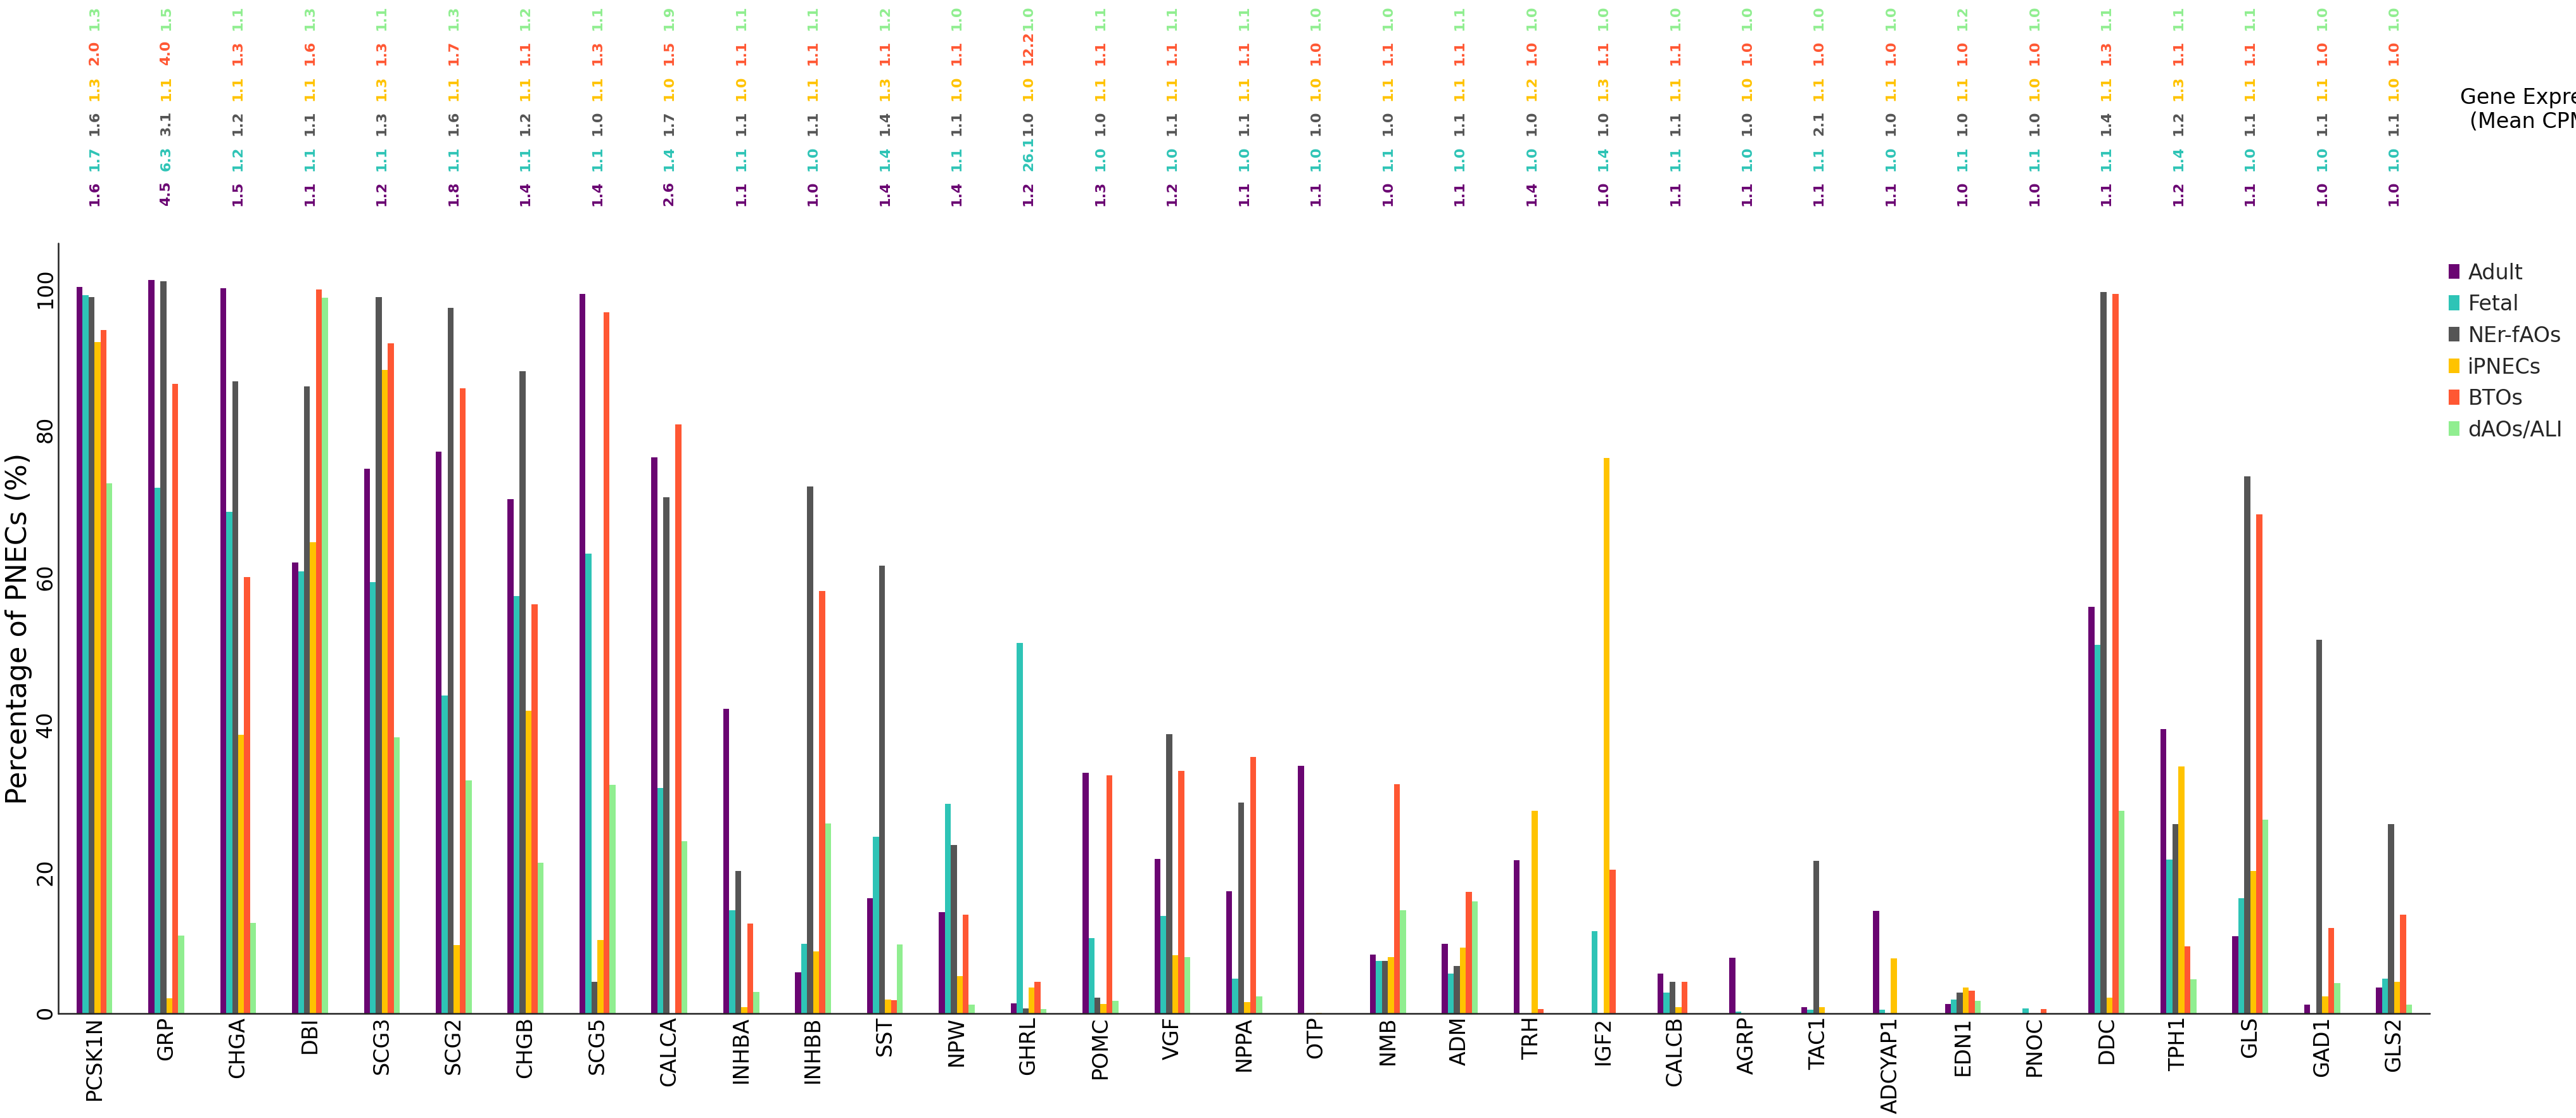

In [25]:
## Figure S4C

# Set the figure size and style based on your preference
plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(60, 20))

# Use the bar function to create a stacked bar plot
genes=[
    #Peptidergic
       'PCSK1N', 'GRP', 'CHGA', 'DBI', 'SCG3', 'SCG2',  'CHGB', 'SCG5',
       'CALCA', 'INHBA',  'INHBB', 'SST', 'NPW', 'GHRL', 'POMC',
       'VGF', 'NPPA', 'OTP',  'NMB', 'ADM',  'TRH',
       'IGF2', 'CALCB', 'AGRP', 'TAC1', 'ADCYAP1', 'EDN1', 'PNOC',
    #Neuroetransmitters
    'DDC','TPH1', 'GLS','GAD1','GLS2']

df_NE_perc_NE = df_NE_perc[df_NE.index.isin(genes)]

df_plot = df_NE_perc_NE[['Adult','Fetal','NEr-fAOs',
                     'iPNECs','BTOs','dAOs/ALI']]

df_plot.plot(kind='bar', stacked=False, color=['#6A0572','#2EC4B6','#555555','#FFC300', '#FF5733', '#90EE90'],
             edgecolor=None,width=0.5, ax=ax)

# Customize the plot
plt.grid(False)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=30)
plt.yticks(size=30,color='black',rotation=90)
plt.xticks(rotation=90, size=30, color='black')
plt.ylabel("Percentage of PNECs (%)", size = 40, color='black')

# Add another axis on top with corresponding ticks and values
ax_adult = ax.twiny()
ax_adult.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_adult.set_xticks(ax.get_xticks())  # Set the positions of the ticks
ax_adult.spines['top'].set_position(('outward', 50))
ax_adult.set_xticklabels(df_NE_perc_NE['Counts Adult'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#6A0572')

ax_fetal = ax.twiny()
ax_fetal.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_fetal.set_xticks(ax.get_xticks())  # Set the positions of the ticks
ax_fetal.spines['top'].set_position(('outward', 100))
ax_fetal.set_xticklabels(df_NE_perc_NE['Counts Fetal'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#2EC4B6')

ax_dayton = ax.twiny()
ax_dayton.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_dayton.set_xticks(ax.get_xticks()) # Set the positions of the ticks
ax_dayton.spines['top'].set_position(('outward', 150))
ax_dayton.set_xticklabels(df_NE_perc_NE['Counts NEr-fAOs'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#555555')
ax_dayton.xaxis.set_label_coords(1.05, 1.05)  # Adjust the label position

ax_iPNECs = ax.twiny()
ax_iPNECs.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_iPNECs.set_xticks(ax.get_xticks())  # Set the positions of the ticks
ax_iPNECs.spines['top'].set_position(('outward', 200))
ax_iPNECs.set_xticklabels(df_NE_perc_NE['Counts iPNECs'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#FFC300')

ax_conchola_organoid = ax.twiny()
ax_conchola_organoid.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_conchola_organoid.set_xticks(ax.get_xticks())  # Set the positions of the ticks
ax_conchola_organoid.spines['top'].set_position(('outward', 250))
ax_conchola_organoid.set_xticklabels(df_NE_perc_NE['Counts BTOs'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#FF5733')

ax_lee = ax.twiny()
ax_lee.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_lee.set_xticks(ax.get_xticks()) # Set the positions of the ticks
ax_lee.spines['top'].set_position(('outward', 300))
ax_lee.set_xticklabels(df_NE_perc_NE['Counts dAOs/ALI'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#90EE90')

ax_lee.set_xlabel("Gene Expression\n(Mean CPM+1)", size=30, color='black')
ax_lee.xaxis.set_label_coords(1.05, 1.15)  # Adjust the label position

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax_adult.spines['top'].set_visible(False)
ax_fetal.spines['top'].set_visible(False)
ax_dayton.spines['top'].set_visible(False)
ax_iPNECs.spines['top'].set_visible(False)
ax_conchola_organoid.spines['top'].set_visible(False)
ax_lee.spines['top'].set_visible(False)
ax_adult.spines['right'].set_visible(False)
ax_fetal.spines['right'].set_visible(False)
ax_dayton.spines['right'].set_visible(False)
ax_iPNECs.spines['right'].set_visible(False)
ax_conchola_organoid.spines['right'].set_visible(False)
ax_lee.spines['right'].set_visible(False)

plt.savefig(os.path.join(figfolder,'BarPlot_Alignment_Neuroendocrine_day10_NE_genes.pdf'),
            bbox_inches='tight', pad_inches=2)

# Show the plot
plt.show()

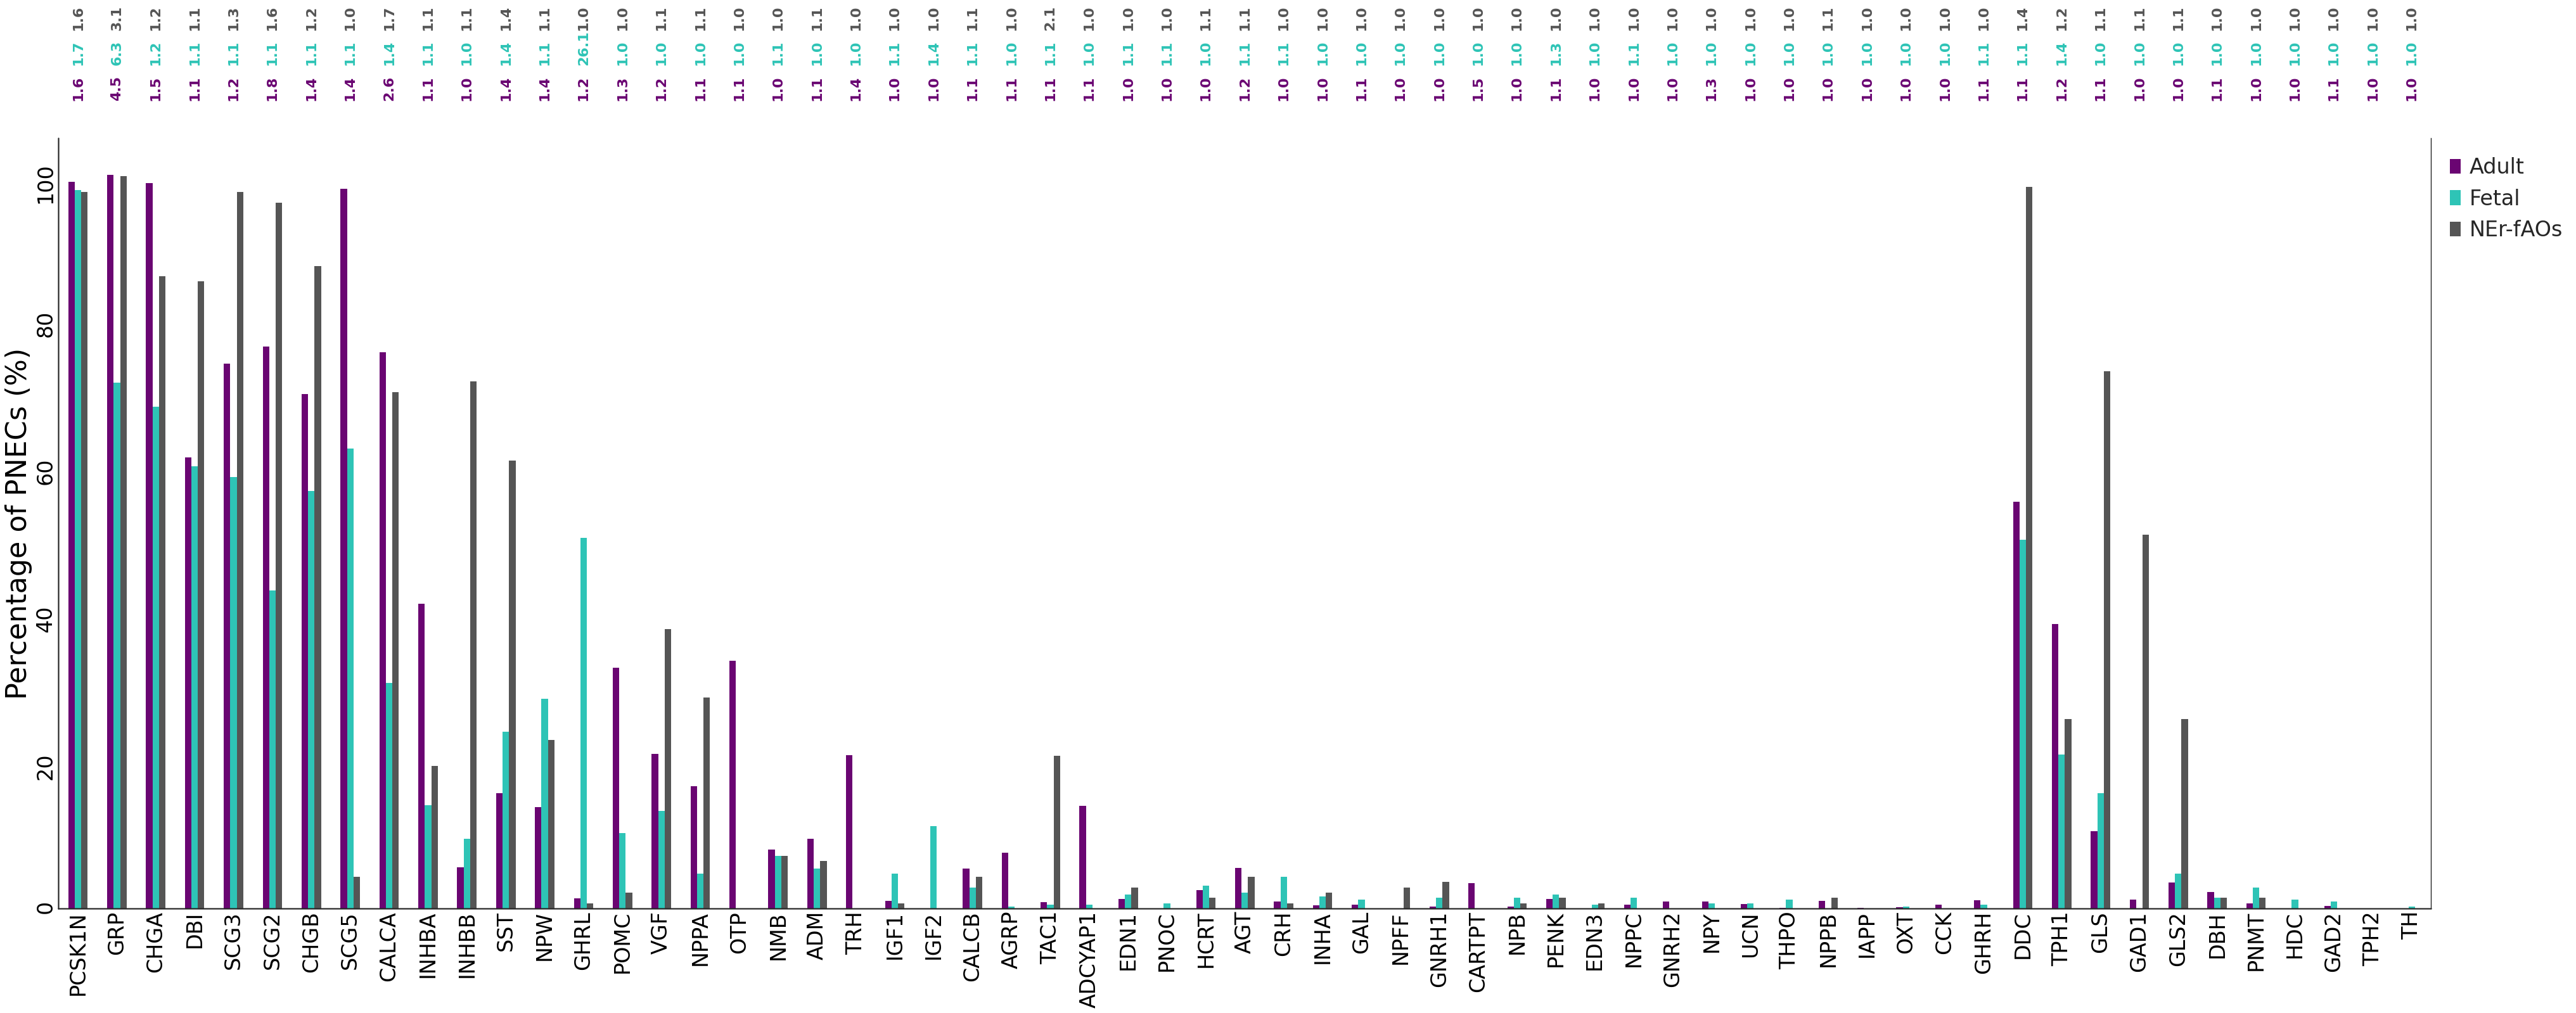

In [26]:
# Set the figure size and style based on your preference
plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(60, 20))

# Use the bar function to create a stacked bar plot
df_plot = df_NE_perc[['Adult','Fetal','NEr-fAOs']]

df_plot.plot(kind='bar', stacked=False, color=['#6A0572','#2EC4B6','#555555'],
             edgecolor=None,width=0.5, ax=ax)

# Customize the plot
plt.grid(False)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=30)
plt.yticks(size=30,color='black',rotation=90)
plt.xticks(rotation=90, size=30, color='black')
plt.ylabel("Percentage of PNECs (%)", size = 40, color='black')

# Add another axis on top with corresponding ticks and values
ax_adult = ax.twiny()
ax_adult.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_adult.set_xticks(ax.get_xticks())  # Set the positions of the ticks
ax_adult.spines['top'].set_position(('outward', 50))
ax_adult.set_xticklabels(df_NE_perc['Counts Adult'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#6A0572')

ax_fetal = ax.twiny()
ax_fetal.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_fetal.set_xticks(ax.get_xticks())  # Set the positions of the ticks
ax_fetal.spines['top'].set_position(('outward', 100))
ax_fetal.set_xticklabels(df_NE_perc['Counts Fetal'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#2EC4B6')

ax_dayton = ax.twiny()
ax_dayton.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_dayton.set_xticks(ax.get_xticks()) # Set the positions of the ticks
ax_dayton.spines['top'].set_position(('outward', 150))
ax_dayton.set_xticklabels(df_NE_perc['Counts NEr-fAOs'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#555555')
ax_dayton.xaxis.set_label_coords(1.05, 1.05)  # Adjust the label position

ax_lee.set_xlabel("Gene Expression\n(Mean CPM+1)", size=30, color='black')
ax_lee.xaxis.set_label_coords(1.05, 1.15)  # Adjust the label position

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax_adult.spines['top'].set_visible(False)
ax_fetal.spines['top'].set_visible(False)
ax_dayton.spines['top'].set_visible(False)
ax_lee.spines['top'].set_visible(False)
ax_adult.spines['right'].set_visible(False)
ax_fetal.spines['right'].set_visible(False)
ax_conchola_organoid.spines['right'].set_visible(False)
ax_lee.spines['right'].set_visible(False)

plt.savefig(os.path.join(figfolder,'BarPlot_Alignment_Neuroendocrine_day10_tissues_all_NE_genes.pdf'),
            bbox_inches='tight', pad_inches=2)

# Show the plot
plt.show()

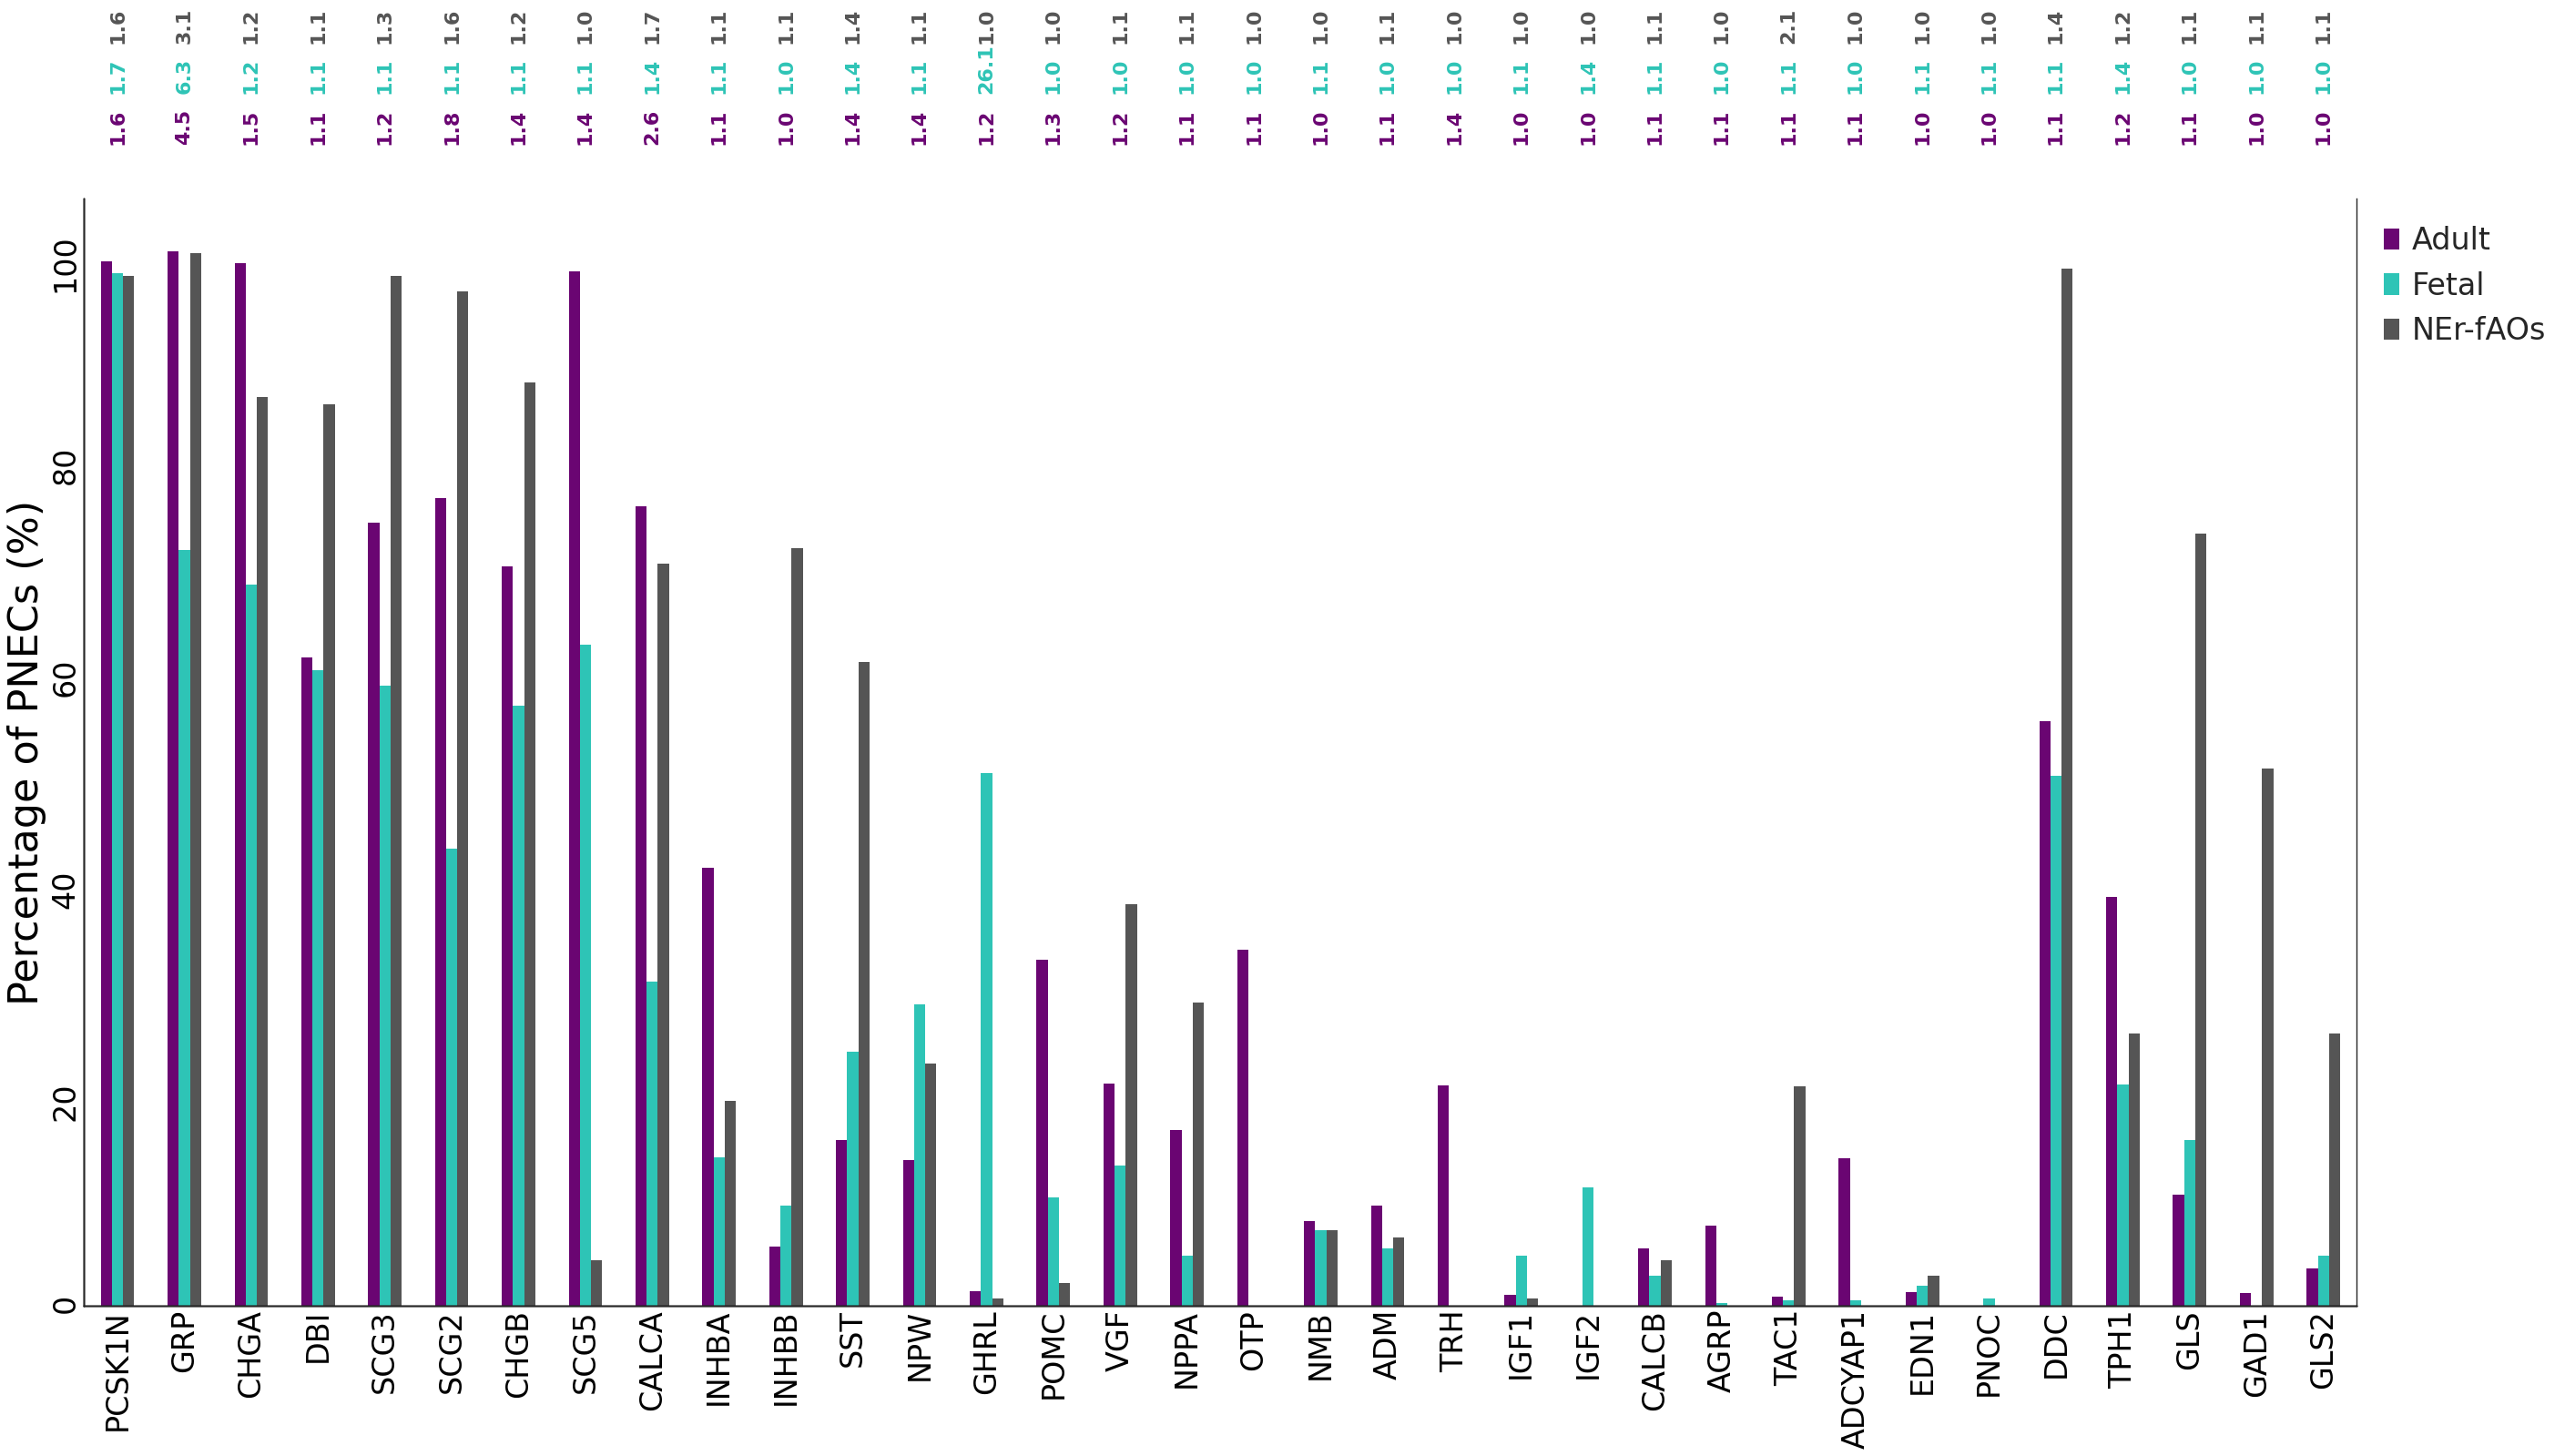

In [27]:
## Figure 4E

# Set the figure size and style based on your preference
plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(40, 20))

# Use the bar function to create a stacked bar plot
genes=[
    #Peptidergic
       'PCSK1N', 'GRP', 'CHGA', 'DBI', 'SCG3', 'SCG2',  'CHGB', 'SCG5',
       'CALCA', 'INHBA',  'INHBB', 'SST', 'NPW', 'GHRL', 'POMC',
       'VGF', 'NPPA', 'OTP',  'NMB', 'ADM',  'TRH', 'IGF1',
       'IGF2', 'CALCB', 'AGRP', 'TAC1', 'ADCYAP1', 'EDN1', 'PNOC',
    #Neuroetransmitters
    'DDC','TPH1', 'GLS','GAD1','GLS2']

df_NE_perc_filtered = df_NE_perc[df_NE.index.isin(genes)]

df_plot = df_NE_perc_filtered[['Adult','Fetal','NEr-fAOs']]


df_plot.plot(kind='bar', stacked=False, color=['#6A0572','#2EC4B6','#555555'],
             edgecolor=None,width=0.5, ax=ax)

# Customize the plot
plt.grid(False)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=30)
plt.yticks(size=30,color='black',rotation=90)
plt.xticks(rotation=90, size=30, color='black')
plt.ylabel("Percentage of PNECs (%)", size = 40, color='black')

# Add another axis on top with corresponding ticks and values
ax_adult = ax.twiny()
ax_adult.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_adult.set_xticks(ax.get_xticks())  # Set the positions of the ticks
ax_adult.spines['top'].set_position(('outward', 50))
ax_adult.set_xticklabels(df_NE_perc_filtered['Counts Adult'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#6A0572')

ax_fetal = ax.twiny()
ax_fetal.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_fetal.set_xticks(ax.get_xticks())  # Set the positions of the ticks
ax_fetal.spines['top'].set_position(('outward', 100))
ax_fetal.set_xticklabels(df_NE_perc_filtered['Counts Fetal'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#2EC4B6')

ax_dayton = ax.twiny()
ax_dayton.set_xlim(ax.get_xlim())  # Set the same x-axis limits as the original axis
ax_dayton.set_xticks(ax.get_xticks()) # Set the positions of the ticks
ax_dayton.spines['top'].set_position(('outward', 150))
ax_dayton.set_xticklabels(df_NE_perc_filtered['Counts NEr-fAOs'].to_list(), fontweight='bold',fontsize=20,rotation=90, color='#555555')
ax_dayton.xaxis.set_label_coords(1.05, 1.05)  # Adjust the label position

ax_lee.set_xlabel("Gene Expression\n(Mean CPM+1)", size=30, color='black')
ax_lee.xaxis.set_label_coords(1.05, 1.15)  # Adjust the label position

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax_adult.spines['top'].set_visible(False)
ax_fetal.spines['top'].set_visible(False)
ax_dayton.spines['top'].set_visible(False)
ax_lee.spines['top'].set_visible(False)
ax_adult.spines['right'].set_visible(False)
ax_fetal.spines['right'].set_visible(False)
ax_conchola_organoid.spines['right'].set_visible(False)
ax_lee.spines['right'].set_visible(False)

plt.savefig(os.path.join(figfolder,'BarPlot_Alignment_Neuroendocrine_day10_tissues_NE_genes.pdf'),
            bbox_inches='tight', pad_inches=2)

# Show the plot
plt.show()